In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer

In [69]:
# Load the dataset
df = pd.read_csv("Boston-house-price-data.csv")

In [70]:
#Features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [72]:
le = LabelEncoder()
X["CHAS"] = le.fit_transform(X["CHAS"])

In [73]:
#One Hot Encoding
ct = ColumnTransformer(transformers=[("onehot", OneHotEncoder(drop='first'), ["CHAS"])],remainder="passthrough")
x = ct.fit_transform(X)

In [74]:
X_encoded = ct.fit_transform(X)

In [75]:
#Polynomial Features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_encoded)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=0
)

In [77]:
#Multi Linear Regression Model
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
#Evaluation

In [79]:
y_pred = reg.predict(X_test)

In [80]:
mse = mean_squared_error(y_pred,y_test)
mse

31.27781497234037

In [81]:
r2 = r2_score(y_test, y_pred)
r2

0.6158858583969172

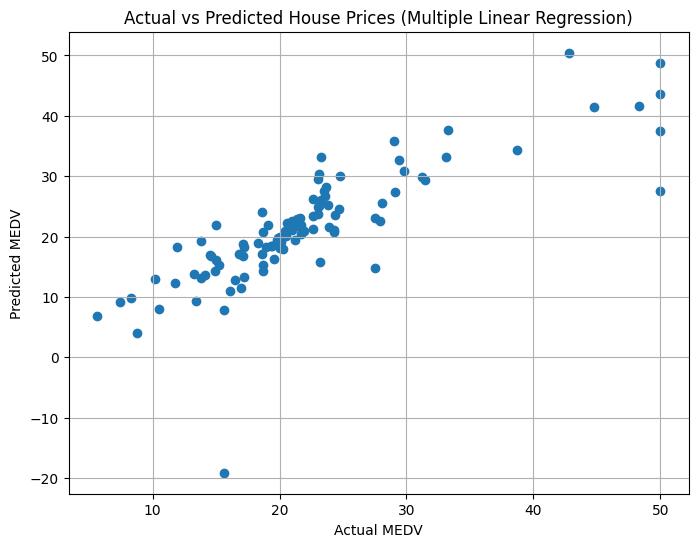

In [82]:
# Predict using the model
y_pred = model.predict(X_test)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices (Multiple Linear Regression)")
plt.grid(True)
plt.show()

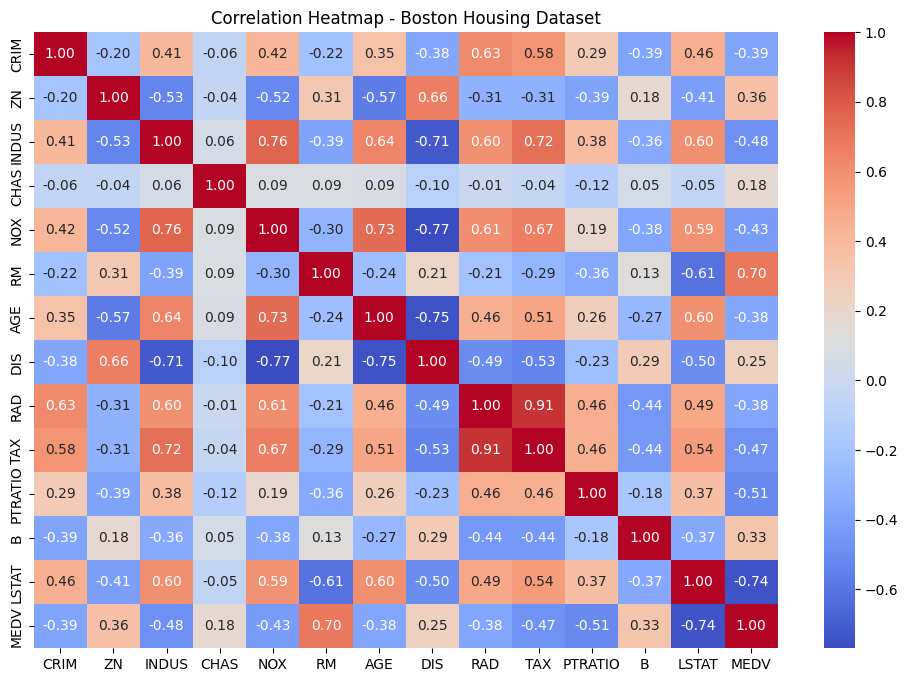

In [83]:
# Compute correlation matrix
corr = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Boston Housing Dataset")
plt.show()